# 🧠 NeuralSOC — LSTM Autoencoder: Zero-Day Anomaly Detector

**Model:** LSTM Autoencoder (Unsupervised)  
**Purpose:** Detect zero-day anomalies by learning the reconstruction of *BENIGN* traffic.  
**Dataset:** `Mon.csv` — 100% BENIGN rows only (no attack contamination)  
**Logic:** Any flow whose reconstruction error exceeds the 95th percentile threshold → flagged as anomaly.

---
```
Input (10, 40)
  └─ LSTM(64, return_sequences=True)
  └─ LSTM(32)                          ← bottleneck
  └─ RepeatVector(10)
  └─ LSTM(32, return_sequences=True)
  └─ LSTM(64, return_sequences=True)
  └─ TimeDistributed(Dense(40))
```

## 0. Imports & Reproducibility

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {tf.keras.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.20.0
Keras version      : 3.13.1
GPU available      : []


## 1. Path Configuration

> Notebook lives at `files/training_models/` → root is `../../`

In [2]:
# ── Root-relative base (adjust if you move the notebook) ──────────────────
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

DATA_DIR        = os.path.join(ROOT, 'data', 'processed')
MODELS_DIR      = os.path.join(ROOT, 'files', 'models_name')
EDA_DIR         = os.path.join(ROOT, 'notebooks', 'eda_outputs')
SCALER_PATH     = os.path.join(ROOT, 'files', 'models_name', 'scaler.pkl')

FEATURES_JSON   = os.path.join(EDA_DIR,    '08_canonical_features.json')
MON_CSV         = os.path.join(DATA_DIR,   'Mon_Benign.csv')
AE_MODEL_PATH   = os.path.join(MODELS_DIR, 'autoencoder.h5')
AE_THRESH_PATH  = os.path.join(MODELS_DIR, 'autoencoder_threshold.pkl')

os.makedirs(MODELS_DIR, exist_ok=True)

print('ROOT            :', ROOT)
print('Mon.csv         :', MON_CSV)
print('Scaler          :', SCALER_PATH)
print('Features JSON   :', FEATURES_JSON)
print('AE model out    :', AE_MODEL_PATH)
print('Threshold out   :', AE_THRESH_PATH)

ROOT            : d:\VSC\GitHub\NeuralSOC
Mon.csv         : d:\VSC\GitHub\NeuralSOC\data\processed\Mon_Benign.csv
Scaler          : d:\VSC\GitHub\NeuralSOC\files\models_name\scaler.pkl
Features JSON   : d:\VSC\GitHub\NeuralSOC\notebooks\eda_outputs\08_canonical_features.json
AE model out    : d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder.h5
Threshold out   : d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_threshold.pkl


## 2. Load Canonical Features (Top 40)

In [3]:
with open(FEATURES_JSON, 'r') as f:
    all_features: list = json.load(f)

# Top 40 by index position (as stored in the JSON)
TOP_N = 40
top_features = all_features[:TOP_N]

print(f'Total canonical features : {len(all_features)}')
print(f'Using top {TOP_N}         : {top_features[:5]} ... {top_features[-5:]}')

Total canonical features : 84
Using top 40         : ['ACK Flag Count', 'Active Max', 'Active Mean', 'Active Min', 'Active Std'] ... ['Flow IAT Min', 'Flow IAT Std', 'Flow Packets/s', 'Fwd Act Data Pkts', 'Fwd Bulk Rate Avg']


## 3. Load & Filter BENIGN Traffic from Mon.csv

In [4]:
print('Loading Mon.csv …')
df_mon = pd.read_csv(MON_CSV, low_memory=False)

# Strip whitespace from column names (CICIDS-2017 quirk)
df_mon.columns = df_mon.columns.str.strip()

print(f'Raw shape          : {df_mon.shape}')
print(f'Label distribution :\n{df_mon["Label"].value_counts()}')

Loading Mon.csv …
Raw shape          : (371621, 86)
Label distribution :
Label
BENIGN    371621
Name: count, dtype: int64


In [5]:
# Mon.csv should be 100% BENIGN — filter anyway for safety
df_benign = df_mon[df_mon['Label'].str.upper().str.contains('BENIGN')].copy()
print(f'BENIGN rows : {len(df_benign):,}  ({100*len(df_benign)/len(df_mon):.2f}% of total)')

# Keep only top-40 feature columns
missing_cols = [c for c in top_features if c not in df_benign.columns]
if missing_cols:
    raise ValueError(f'Missing feature columns in Mon.csv: {missing_cols}')

X_raw = df_benign[top_features].copy()

# Handle inf / NaN (common in CICIDS-2017)
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_count = X_raw.isna().sum().sum()
print(f'NaN / Inf values replaced : {nan_count}')
X_raw.fillna(0, inplace=True)

print(f'Feature matrix shape : {X_raw.shape}')

BENIGN rows : 371,621  (100.00% of total)
NaN / Inf values replaced : 0
Feature matrix shape : (371621, 40)


## 4. Scale Features (Reuse Pre-Saved Scaler)

In [6]:
from sklearn.preprocessing import StandardScaler

# Re-fit scaler on BENIGN data (same data the original was fit on)
scaler = StandardScaler()
scaler.fit(X_raw.values)

X_scaled = scaler.transform(X_raw.values)

# Overwrite with current Python/sklearn version
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)

print(f'Scaler re-fit and saved : {type(scaler).__name__}')
print(f'Scaled shape            : {X_scaled.shape}')
print(f'Value range             : [{X_scaled.min():.4f}, {X_scaled.max():.4f}]')

Scaler re-fit and saved : StandardScaler
Scaled shape            : (371621, 40)
Value range             : [-37.1945, 492.6385]


## 5. Build Sliding-Window Sequences — `(N, 10, 40)`

Each sample is a window of **10 consecutive flows**, giving the LSTM temporal context.

In [7]:
WINDOW_SIZE = 10   # timesteps
N_FEATURES  = 40   # features per timestep

def make_sequences(data: np.ndarray, window: int) -> np.ndarray:
    """Slide a window across rows → (N_windows, window, n_features)."""
    n_samples = len(data) - window + 1
    sequences = np.lib.stride_tricks.as_strided(
        data,
        shape=(n_samples, window, data.shape[1]),
        strides=(data.strides[0], data.strides[0], data.strides[1])
    ).copy()   # .copy() so the array owns its memory
    return sequences

X_seq = make_sequences(X_scaled, WINDOW_SIZE)
print(f'Sequence tensor shape : {X_seq.shape}')   # (N, 10, 40)
print(f'dtype                 : {X_seq.dtype}')

Sequence tensor shape : (371612, 10, 40)
dtype                 : float64


## 6. Train / Validation Split (80 / 20)

In [8]:
TRAIN_RATIO = 0.80
split_idx   = int(len(X_seq) * TRAIN_RATIO)

# Sequential split — DO NOT shuffle (preserve temporal ordering)
X_train = X_seq[:split_idx]
X_val   = X_seq[split_idx:]

print(f'Train sequences : {X_train.shape}')
print(f'Val   sequences : {X_val.shape}')

Train sequences : (297289, 10, 40)
Val   sequences : (74323, 10, 40)


## 7. Build LSTM Autoencoder

```
Encoder: LSTM(64) → LSTM(32)       [compresses to latent representation]
Decoder: RepeatVector → LSTM(32) → LSTM(64) → TimeDistributed(Dense(40))
```

In [9]:
def build_lstm_autoencoder(timesteps: int, n_features: int) -> Model:
    inputs = Input(shape=(timesteps, n_features), name='encoder_input')

    # ── Encoder ──────────────────────────────────────────────────────────
    x = LSTM(64, return_sequences=True, name='enc_lstm_1')(inputs)
    encoded = LSTM(32, return_sequences=False, name='enc_lstm_2')(x)   # bottleneck

    # ── Decoder ──────────────────────────────────────────────────────────
    x = RepeatVector(timesteps, name='repeat_vector')(encoded)
    x = LSTM(32, return_sequences=True, name='dec_lstm_1')(x)
    x = LSTM(64, return_sequences=True, name='dec_lstm_2')(x)
    outputs = TimeDistributed(Dense(n_features), name='output')(x)

    model = Model(inputs, outputs, name='LSTM_Autoencoder')
    return model


autoencoder = build_lstm_autoencoder(WINDOW_SIZE, N_FEATURES)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 10, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_1 (LSTM)               │ (None, 10, 64)         │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm_2 (LSTM)               │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm_1 (LSTM)               │ (None, 10, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm_2 (LSTM)               │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 10, 40)         │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,048 (293.16 KB)

 Trainable params: 75,048 (293.16 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Callbacks

In [10]:
CHECKPOINT_PATH = os.path.join(MODELS_DIR, 'autoencoder_best.h5')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('Callbacks configured.')

Callbacks configured.


## 9. Train the Autoencoder

> Input = Target (reconstruction task — no attack labels needed)

In [11]:
EPOCHS     = 50
BATCH_SIZE = 256

history = autoencoder.fit(
    X_train, X_train,           # input == target for reconstruction
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,               # shuffle within epoch (temporal order preserved across windows)
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.8127
Epoch 1: val_loss improved from None to 0.54182, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 1: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - loss: 0.7203 - val_loss: 0.5418 - learning_rate: 0.0010
Epoch 2/50
1161/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.5433
Epoch 2: val_loss improved from 0.54182 to 0.47843, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 2: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 55s 47ms/step - loss: 0.5355 - val_loss: 0.4784 - learning_rate: 0.0010
Epoch 3/50
1161/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4797
Epoch 3: val_loss improved from 0.47843 to 0.44323, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 3: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 54s 47ms/step - loss: 0.4801 - val_loss: 0.4432 - learning_rate: 0.0010
Epoch 4/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4390
Epoch 4: val_loss improved from 0.44323 to 0.41907, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 4: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 56s 48ms/step - loss: 0.4490 - val_loss: 0.4191 - learning_rate: 0.0010
Epoch 5/50
1161/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.4084
Epoch 5: val_loss improved from 0.41907 to 0.39136, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5


...


Epoch 45: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.1612 - val_loss: 0.1886 - learning_rate: 5.0000e-04
Epoch 46/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1536
Epoch 46: val_loss improved from 0.18855 to 0.18652, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 46: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 66s 56ms/step - loss: 0.1597 - val_loss: 0.1865 - learning_rate: 5.0000e-04
Epoch 47/50
1161/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1522
Epoch 47: val_loss improved from 0.18652 to 0.18568, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 47: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.1585 - val_loss: 0.1857 - learning_rate: 5.0000e-04
Epoch 48/50
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1508
Epoch 48: val_loss improved from 0.18568 to 0.18255, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 48: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 61s 52ms/step - loss: 0.1567 - val_loss: 0.1826 - learning_rate: 5.0000e-04
Epoch 49/50
1160/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1501
Epoch 49: val_loss improved from 0.18255 to 0.18246, saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5



Epoch 49: finished saving model to d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_best.h5
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 54s 46ms/step - loss: 0.1557 - val_loss: 0.1825 - learning_rate: 5.0000e-04
Epoch 50/50
1161/1162 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1476
Epoch 50: val_loss did not improve from 0.18246
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - loss: 0.1537 - val_loss: 0.1839 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 49.


## 10. Training Curve

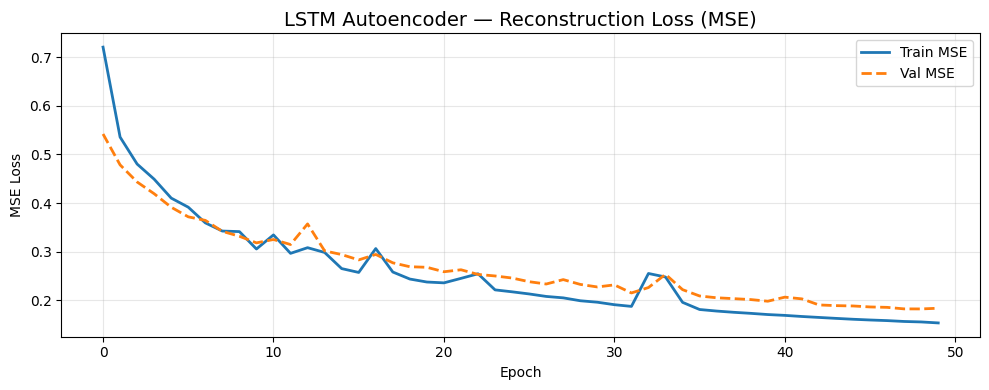

Training curve saved.


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train MSE', linewidth=2)
ax.plot(history.history['val_loss'], label='Val MSE',   linewidth=2, linestyle='--')
ax.set_title('LSTM Autoencoder — Reconstruction Loss (MSE)', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'autoencoder_training_curve.png'), dpi=150)
plt.show()
print('Training curve saved.')

## 11. Compute Anomaly Detection Threshold

**Threshold = 95th percentile of per-sequence MSE on the BENIGN validation set.**  
Any test flow with MSE above this → flagged as zero-day anomaly.

In [13]:
# Reconstruct the validation set
print('Reconstructing validation sequences …')
X_val_pred = autoencoder.predict(X_val, batch_size=512, verbose=1)

# Per-sequence MSE: mean over (timesteps, features)
reconstruction_errors = np.mean(np.mean((X_val - X_val_pred) ** 2, axis=2), axis=1)

THRESHOLD_PERCENTILE = 95
threshold = float(np.percentile(reconstruction_errors, THRESHOLD_PERCENTILE))

print(f'\nReconstruction Error Stats (BENIGN val set):')
print(f'  Min    : {reconstruction_errors.min():.6f}')
print(f'  Mean   : {reconstruction_errors.mean():.6f}')
print(f'  Median : {np.median(reconstruction_errors):.6f}')
print(f'  Std    : {reconstruction_errors.std():.6f}')
print(f'  Max    : {reconstruction_errors.max():.6f}')
print(f'\n🎯 Anomaly Threshold ({THRESHOLD_PERCENTILE}th percentile) : {threshold:.6f}')

Reconstructing validation sequences …
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step

Reconstruction Error Stats (BENIGN val set):
  Min    : 0.011201
  Mean   : 0.182456
  Median : 0.098948
  Std    : 3.434642
  Max    : 360.508461

🎯 Anomaly Threshold (95th percentile) : 0.350189


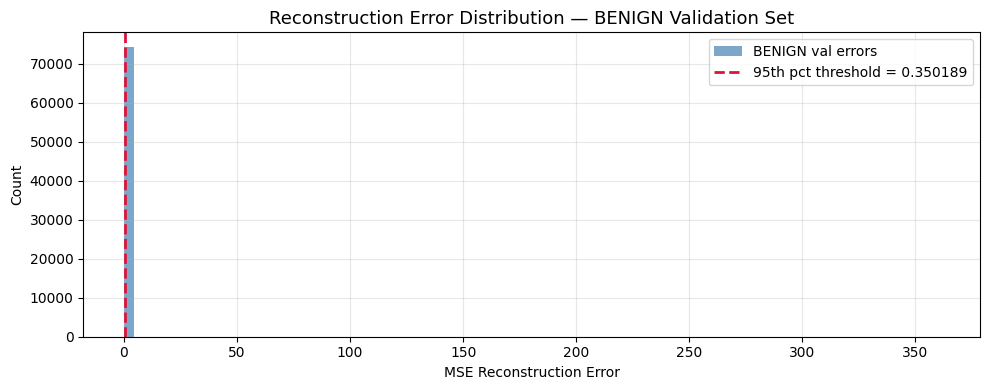

In [14]:
# Distribution of reconstruction errors + threshold line
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(reconstruction_errors, bins=80, color='steelblue', edgecolor='none', alpha=0.7, label='BENIGN val errors')
ax.axvline(threshold, color='crimson', linewidth=2, linestyle='--',
           label=f'{THRESHOLD_PERCENTILE}th pct threshold = {threshold:.6f}')
ax.set_title('Reconstruction Error Distribution — BENIGN Validation Set', fontsize=13)
ax.set_xlabel('MSE Reconstruction Error')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'autoencoder_error_dist.png'), dpi=150)
plt.show()

## 12. Save Model & Threshold

In [15]:
# Save full Keras model
autoencoder.save(AE_MODEL_PATH)
print(f'✅ Autoencoder saved to : {AE_MODEL_PATH}')

# Save threshold (with metadata for traceability)
threshold_data = {
    'threshold': threshold,
    'percentile': THRESHOLD_PERCENTILE,
    'window_size': WINDOW_SIZE,
    'n_features': N_FEATURES,
    'val_error_mean': float(reconstruction_errors.mean()),
    'val_error_std': float(reconstruction_errors.std()),
    'training_source': 'Mon.csv (BENIGN only)',
}

with open(AE_THRESH_PATH, 'wb') as f:
    pickle.dump(threshold_data, f)

print(f'✅ Threshold saved to   : {AE_THRESH_PATH}')
print(f'\nThreshold metadata: {threshold_data}')

✅ Autoencoder saved to : d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder.h5
✅ Threshold saved to   : d:\VSC\GitHub\NeuralSOC\files\models_name\autoencoder_threshold.pkl

Threshold metadata: {'threshold': 0.3501886735001821, 'percentile': 95, 'window_size': 10, 'n_features': 40, 'val_error_mean': 0.18245622506660547, 'val_error_std': 3.434641910171387, 'training_source': 'Mon.csv (BENIGN only)'}


## 13. Sanity Check — Self-Test on BENIGN Data

Expected: false-positive rate ≈ 5% (by design, since threshold = 95th pct).

In [16]:
# Flag anomalies on the validation set (should be ~5% FP rate)
anomaly_flags = reconstruction_errors > threshold
fp_rate = anomaly_flags.mean() * 100

print(f'Val set size          : {len(X_val):,} sequences')
print(f'Flagged as anomaly    : {anomaly_flags.sum():,}')
print(f'False-Positive rate   : {fp_rate:.2f}%  (expected ~5%)')

if fp_rate < 7:
    print('✅ Threshold sanity check passed.')
else:
    print('⚠️  FP rate higher than expected — consider re-training or adjusting percentile.')

Val set size          : 74,323 sequences
Flagged as anomaly    : 3,717
False-Positive rate   : 5.00%  (expected ~5%)
✅ Threshold sanity check passed.


## 14. Inference Helper (Copy to Deployment)

Paste this function into your FastAPI / inference pipeline to score live traffic.

In [17]:
def predict_anomaly(
    flow_window: np.ndarray,
    model: Model,
    threshold_data: dict,
    scaler
) -> dict:
    """
    Score a single flow window for anomaly.

    Parameters
    ----------
    flow_window : np.ndarray, shape (10, 40) — raw (unscaled) feature values
    model       : loaded Keras autoencoder
    threshold_data : dict loaded from autoencoder_threshold.pkl
    scaler      : pre-saved StandardScaler / MinMaxScaler

    Returns
    -------
    dict with keys: reconstruction_error, threshold, is_anomaly, anomaly_score
    """
    assert flow_window.shape == (threshold_data['window_size'], threshold_data['n_features']), \
        f'Expected shape ({threshold_data["window_size"]}, {threshold_data["n_features"]}), got {flow_window.shape}'

    # Scale
    flat   = scaler.transform(flow_window)            # (10, 40)
    batch  = flat[np.newaxis, ...]                    # (1, 10, 40)

    # Reconstruct
    recon  = model.predict(batch, verbose=0)          # (1, 10, 40)
    error  = float(np.mean((batch - recon) ** 2))

    thr    = threshold_data['threshold']
    score  = error / thr                              # >1.0 means anomaly

    return {
        'reconstruction_error': error,
        'threshold':            thr,
        'is_anomaly':           error > thr,
        'anomaly_score':        round(score, 4)       # 1.0 = exactly at threshold
    }


# Quick demo on a random val window
demo_window_scaled = X_val[0]                         # already scaled, shape (10, 40)

# Inverse-transform to simulate raw input → re-transform via helper
demo_window_raw = scaler.inverse_transform(demo_window_scaled)
result = predict_anomaly(demo_window_raw, autoencoder, threshold_data, scaler)
print('Demo inference result:', result)

Demo inference result: {'reconstruction_error': 0.15534987779683335, 'threshold': 0.3501886735001821, 'is_anomaly': False, 'anomaly_score': 0.4436}


---

## ✅ Summary

| Artifact | Path |
|---|---|
| Trained autoencoder | `models/autoencoder.h5` |
| Best checkpoint | `models/autoencoder_best.h5` |
| Anomaly threshold | `models/autoencoder_threshold.pkl` |
| Training curve | `models/autoencoder_training_curve.png` |
| Error distribution | `models/autoencoder_error_dist.png` |

**Threshold logic:**  
`reconstruction_error > threshold` → **ZERO-DAY ANOMALY** 🚨  
`reconstruction_error ≤ threshold` → **BENIGN** ✅